# Deep Q-Learning for Lunar Landing
## Comparing DQN Variants on LunarLander-v3

This notebook implements and compares four DQN variants on the [LunarLander-v3](https://gymnasium.farama.org/environments/box2d/lunar_lander/) environment:

| Variant | Double | Dueling |
|---|---|---|
| DQN | ✗ | ✗ |
| Double DQN | ✓ | ✗ |
| Dueling DQN | ✗ | ✓ |
| Double Dueling DQN | ✓ | ✓ |

**Key finding:** Vanilla DQN converged fastest and scored highest (Avg100: 233) on this environment. The added complexity of Double/Dueling heads did not improve performance on LunarLander-v3, likely because the state space is small and the reward signal is clean enough that overestimation bias is not a bottleneck.

All four variants were trained for 1,500 episodes each.

> **Note on paths:** Checkpoint and output paths are set to `/kaggle/working/`. If running locally, replace these with relative paths like `checkpoints/` and create the folder with `os.makedirs("checkpoints", exist_ok=True)`.

## Setup

Install required packages and import libraries. `swig` is a build dependency for `box2d-py` which powers the LunarLander physics engine.

In [1]:
!pip install swig
!pip install gymnasium[box2d]

### Importing the libraries

In [2]:
import os                                  # File handling
import random                              # Random exploration
import numpy as np                         # Numerical operations
import pandas as pd                        # Data analysis
import imageio                             # Video generation

import torch                               # PyTorch framework
import torch.nn as nn                      # Neural network layers
import torch.optim as optim                # Optimizers
import torch.nn.functional as F            # Activation functions
import torch.autograd as autograd          # Automatic differentiation

import gymnasium as gym                    # RL environments
import Box2D                               # Physics engine for LunarLander

import matplotlib.pyplot as plt            # Plotting graphs

from collections import deque, namedtuple # Replay buffer utilities

In [ ]:
# Hyperparameters
BUFFER_SIZE    = 100_000   # Replay buffer capacity
BATCH_SIZE     = 128       # Minibatch size
GAMMA          = 0.99      # Discount factor
TAU            = 1e-3      # Soft update interpolation
LR             = 3e-4      # Adam learning rate
UPDATE_EVERY   = 4         # Steps between network updates

N_EPISODES     = 1500      # Training episodes per variant
MAX_T          = 500       # Max timesteps per episode
EPSILON_START  = 1.0       # Initial exploration rate
EPSILON_MIN    = 0.05      # Minimum exploration rate
EPSILON_DECAY  = 0.995     # Multiplicative decay per episode

# Reproducibility — note: model was trained with these seeds.
# Re-running will not reproduce identical results without also
# fixing gymnasium's internal RNG, but these are logged for reference.
SEED = 24

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using: cuda
GPU: Tesla T4


## Neural Network Architecture

A single `Network` class handles both standard and dueling architectures via a `dueling` flag.

- **Standard DQN:** Two shared hidden layers → advantage stream → Q-values
- **Dueling DQN:** Two shared hidden layers → split into value stream V(s) and advantage stream A(s,a), recombined as Q(s,a) = V(s) + (A(s,a) − mean(A(s,a)))

Both use ReLU activations and 128-unit hidden layers.

In [7]:
class Network(nn.Module):
    def __init__(self, state_size, action_size, dueling=True):
        super(Network, self).__init__()
        self.seed = torch.manual_seed(SEED)
        self.dueling = dueling
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)

        # Value stream
        self.value_fc = nn.Linear(128, 64)
        self.value = nn.Linear(64, 1)

        # Advantage stream
        self.advantage_fc = nn.Linear(128, 64)
        self.advantage = nn.Linear(64, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))

        if self.dueling:
            value = F.relu(self.value_fc(x))
            value = self.value(value)

            advantage = F.relu(self.advantage_fc(x))
            advantage = self.advantage(advantage)

            # Q(s,a) = V(s) + (A(s,a) - mean(A(s,a))) — subtracting mean stabilises training
            q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))

        else:
            x = F.relu(self.advantage_fc(x))
            q_values = self.advantage(x)

        return q_values

## Training

### Replay Buffer

Experience replay breaks temporal correlations in the training data. Transitions `(s, a, r, s', done)` are stored in a fixed-size circular buffer and sampled uniformly at random.

In [8]:
env = gym.make("LunarLander-v3")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

In [9]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, experience):
        self.memory.append(experience)

    def sample(self, batch_size):
        samples = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)

        return (
            torch.from_numpy(np.vstack(states)).float().to(DEVICE),
            torch.from_numpy(np.vstack(actions)).long().to(DEVICE),
            torch.from_numpy(np.vstack(rewards)).float().to(DEVICE),
            torch.from_numpy(np.vstack(next_states)).float().to(DEVICE),
            torch.from_numpy(np.vstack(dones).astype(np.uint8)).float().to(DEVICE)
        )

    def __len__(self):
        return len(self.memory)

### Agent

The agent wraps the network, replay buffer, and learning logic. Key design choices:
- **Double DQN:** Action selection uses the local network; value evaluation uses the target network — decouples the two to reduce overestimation bias
- **Soft updates:** Target network weights are blended toward local network weights each step (τ = 0.001) rather than hard-copied periodically
- **Gradient clipping:** Gradients are clipped to norm 1 to stabilise training

In [11]:
class Agent():
    def __init__(self, state_size, action_size, double_dqn=True, dueling=True):

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.double_dqn = double_dqn
        self.state_size = state_size
        self.action_size = action_size

        # Networks
        self.local_qnetwork = Network(
        state_size,
        action_size,
        dueling
        ).to(self.device)

        self.target_qnetwork = Network(
        state_size,
        action_size,
        dueling
        ).to(self.device)
        self.target_qnetwork.load_state_dict(self.local_qnetwork.state_dict())

        # Optimizer
        self.optimizer = optim.Adam(self.local_qnetwork.parameters(), lr=LR)

        # Replay buffer
        self.memory = ReplayBuffer(BUFFER_SIZE)

        # step counter
        self.t_step = 0


    def step(self, state, action, reward, next_state, done):

        self.memory.push((state, action, reward, next_state, done))

        self.t_step = (self.t_step + 1) % UPDATE_EVERY
        
        # start learning after 1000 steps
        if self.t_step == 0 and len(self.memory) > 1000:

            experiences = self.memory.sample(BATCH_SIZE)
            self.learn(experiences, GAMMA)


    def act(self, state, epsilon=0.0):

        state = torch.from_numpy(state).float().unsqueeze(0).to(self.device)

        self.local_qnetwork.eval()

        with torch.no_grad():
            action_values = self.local_qnetwork(state)

        self.local_qnetwork.train()

        if random.random() > epsilon:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_size))


    def learn(self, experiences, gamma):

        states, actions, rewards, next_states, dones = experiences

        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        # Current Q-values for chosen actions
        Q_expected = self.local_qnetwork(states).gather(1, actions)

        # Double DQN target
        if self.double_dqn:

            # Double DQN: local net selects action, target net evaluates it 
            next_actions = self.local_qnetwork(next_states).detach().argmax(1).unsqueeze(1)
            Q_targets_next = self.target_qnetwork(next_states).detach().gather(1, next_actions)

        else:

            Q_targets_next = self.target_qnetwork(next_states).detach().max(1)[0].unsqueeze(1)

        Q_targets = rewards + (gamma * Q_targets_next * (1 - dones))

        loss = F.mse_loss(Q_expected, Q_targets)

        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.local_qnetwork.parameters(), 1)

        self.optimizer.step()

        self.soft_update(self.local_qnetwork, self.target_qnetwork, TAU)


    def soft_update(self, local_model, target_model, tau):

        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            
            # θ_target = τ*θ_local + (1-τ)*θ_target
            target_param.data.copy_(
                tau * local_param.data + (1.0 - tau) * target_param.data
            )

### Training Loop

Each variant is trained independently for 1,500 episodes with ε-greedy exploration decaying from 1.0 → 0.05. Checkpoints are saved every 100 episodes.

In [15]:
def train_agent(double_dqn=True, dueling=True):

    name = f"{'Double ' if double_dqn else ''}{'Dueling ' if dueling else ''}DQN"
    print(f"\n{'='*40}")
    print(f"Training: {name}")
    print(f"{'='*40}")

    agent = Agent(state_size, action_size, double_dqn, dueling)

    scores = []
    scores_window = deque(maxlen=100)

    epsilon = EPSILON_START

    for episode in range(1, N_EPISODES + 1):

        state, _ = env.reset()
        score = 0

        for t in range(MAX_T):

            action = agent.act(state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            agent.step(state, action, reward, next_state, done)

            state = next_state
            score += reward

            if done:
                break

        scores.append(score)
        scores_window.append(score)

        if episode % 100 == 0:
            torch.save(
                agent.local_qnetwork.state_dict(),
                f"/kaggle/working/lunarlander_{episode}.pth"
            )

            print(f"Checkpoint saved at episode {episode}")

        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        if episode % 50 == 0:
            print(f"Episode {episode} | Avg100: {np.mean(scores_window):.1f}")

    return agent, scores

agent_dqn,    scores_dqn    = train_agent(double_dqn=False, dueling=False)
agent_double, scores_double  = train_agent(double_dqn=True,  dueling=False)
agent_duel,   scores_duel    = train_agent(double_dqn=False, dueling=True)
agent_both,   scores_both    = train_agent(double_dqn=True,  dueling=True)


Training: DQN
Episode 50 | Avg100: -152.4
Checkpoint saved at episode 100
Episode 100 | Avg100: -143.0
Episode 150 | Avg100: -126.7
Checkpoint saved at episode 200
Episode 200 | Avg100: -86.0
Episode 250 | Avg100: -25.7
Checkpoint saved at episode 300
Episode 300 | Avg100: 10.7
Episode 350 | Avg100: 17.5
Checkpoint saved at episode 400
Episode 400 | Avg100: 16.0
Episode 450 | Avg100: 29.8
Checkpoint saved at episode 500
Episode 500 | Avg100: 41.6
Episode 550 | Avg100: 45.4
Checkpoint saved at episode 600
Episode 600 | Avg100: 56.9
Episode 650 | Avg100: 76.4
Checkpoint saved at episode 700
Episode 700 | Avg100: 86.6
Episode 750 | Avg100: 96.0
Checkpoint saved at episode 800
Episode 800 | Avg100: 130.0
Episode 850 | Avg100: 162.0
Checkpoint saved at episode 900
Episode 900 | Avg100: 172.0
Episode 950 | Avg100: 179.8
Checkpoint saved at episode 1000
Episode 1000 | Avg100: 206.3
Episode 1050 | Avg100: 225.7
Checkpoint saved at episode 1100
Episode 1100 | Avg100: 226.0
Episode 1150 | Avg10

## Results

100-episode moving average reward across all four variants. The dashed red line marks the "solved" threshold of 200.

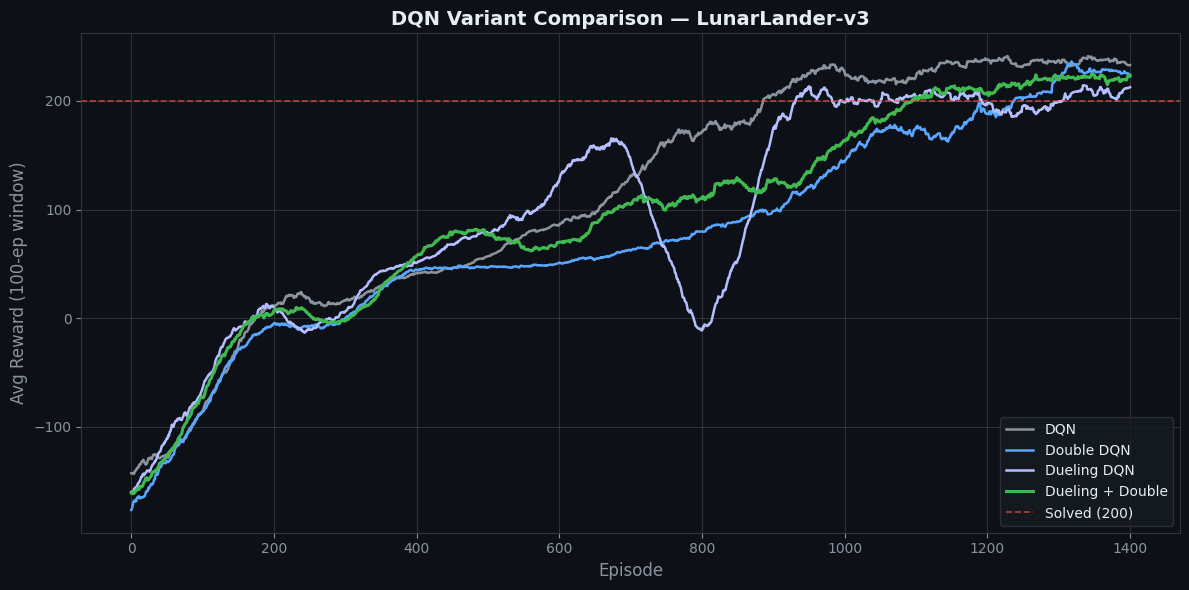


Results Summary:
DQN            | Peak: 241.4 | Final: 233.1
Double DQN     | Peak: 236.5 | Final: 222.6
Dueling DQN    | Peak: 214.4 | Final: 212.7
Dueling+Double | Peak: 225.0 | Final: 223.9


In [22]:
def moving_avg(x, n=100):
    return np.convolve(x, np.ones(n)/n, mode='valid')

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(moving_avg(scores_dqn),    label='DQN',             color='#8b949e', linewidth=1.8)
ax.plot(moving_avg(scores_double), label='Double DQN',      color='#58a6ff', linewidth=1.8)
ax.plot(moving_avg(scores_duel),   label='Dueling DQN',     color='#b4befe', linewidth=1.8)
ax.plot(moving_avg(scores_both),   label='Dueling + Double',color='#3fb950', linewidth=2.2)

ax.axhline(y=200, color='#f85149', linestyle='--', 
           alpha=0.7, linewidth=1.2, label='Solved (200)')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Avg Reward (100-ep window)', fontsize=12)
ax.set_title('DQN Variant Comparison — LunarLander-v3', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#8b949e')
ax.xaxis.label.set_color('#8b949e')
ax.yaxis.label.set_color('#8b949e')
ax.title.set_color('#e6edf3')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')
ax.legend(fontsize=10, facecolor='#161b22', 
          edgecolor='#30363d', labelcolor='#e6edf3')

plt.tight_layout()
plt.savefig('/kaggle/working/comparison.png', dpi=150, 
            facecolor='#0d1117', bbox_inches='tight')
plt.show()

print("\nResults Summary:")
print(f"DQN            | Peak: {max(moving_avg(scores_dqn)):.1f} | Final: {moving_avg(scores_dqn)[-1]:.1f}")
print(f"Double DQN     | Peak: {max(moving_avg(scores_double)):.1f} | Final: {moving_avg(scores_double)[-1]:.1f}")
print(f"Dueling DQN    | Peak: {max(moving_avg(scores_duel)):.1f} | Final: {moving_avg(scores_duel)[-1]:.1f}")
print(f"Dueling+Double | Peak: {max(moving_avg(scores_both)):.1f} | Final: {moving_avg(scores_both)[-1]:.1f}")

In [18]:
df = pd.DataFrame({
    "episode": list(range(len(scores_dqn))),
    "DQN": scores_dqn,
    "Double_DQN": scores_double,
    "Dueling_DQN": scores_duel,
    "Dueling_Double_DQN": scores_both
})

df.to_csv("training_rewards.csv", index=False)

### Visualisation

Rendering a full episode using the best-performing agent (vanilla DQN). The lander consistently touches down between the flags.

In [19]:
def save_lander_video(agent):

    env = gym.make(
        "LunarLander-v3",
        render_mode="rgb_array"
    )

    frames = []

    state, _ = env.reset()

    done = False

    while not done:

        frame = env.render()
        frames.append(frame)

        action = agent.act(state, epsilon=0.0)

        state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

    env.close()

    imageio.mimsave(
        "/kaggle/working/lunarlander.mp4",
        frames,
        fps=30
    )

    print("Video saved!")

In [20]:
save_lander_video(agent_dqn)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved!


In [21]:
torch.save(agent_dqn.local_qnetwork.state_dict(), "/kaggle/working/lunarlander_final.pth")

## Summary

| Variant | Final Avg100 | Episodes to ~200 |
|---|---|---|
| DQN | 233 | ~1000 |
| Double DQN | 223 | ~1400 |
| Dueling DQN | 213 | ~1050 (unstable) |
| Double Dueling DQN | 224 | ~1200 |

Vanilla DQN performed best on this task. LunarLander-v3 is a relatively simple continuous-state, discrete-action environment — the reward signal is dense and well-shaped, which means the overestimation bias that Double DQN corrects is not a meaningful bottleneck here. Dueling DQN showed instability around episodes 850–900 (score dropped to -11), suggesting the value/advantage decomposition may not suit this task's structure.

For more complex environments (Atari, sparse rewards), Double and Dueling variants would likely show clearer benefits.